In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Dataset using your path
file_path = r"C:\Users\vsri9\Downloads\Mayiladuthurai_Final_Dataset.csv"
df = pd.read_csv(file_path)

# 2. Recommended_Crop Logic
def suggest_crop(row):
    if row['Rainfall'] > 1100: return 'Paddy'
    elif row['Potassium'] > 30: return 'Banana'
    elif row['Phosphorus'] > 60: return 'Sugarcane'
    else: return 'Pulses'

df['Recommended_Crop'] = df.apply(suggest_crop, axis=1)

# 3. Accuracy
np.random.seed(42)
noise_indices = df.sample(frac=0.10).index
df.loc[noise_indices, 'Recommended_Crop'] = np.random.choice(['Paddy', 'Banana', 'Sugarcane', 'Pulses'], size=len(noise_indices))

# 4. Features & Target
X = df[['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Temperature', 'Humidity', 'Rainfall']]
y = df['Recommended_Crop']

# 5. Stratified Split (Training: 70%, Testing: 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Cell 1 Success: Data loaded from Downloads.")

Cell 1 Success: Data loaded from Downloads.


In [3]:
# 1. Train Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Evaluation
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred) * 100

print("--- FINAL OPTIMIZED PERFORMANCE ---")
print(f"Accuracy: {acc:.2f}%") 

print("\n--- CLASSIFICATION REPORT (Precision & Recall) ---")
print(classification_report(y_test, y_pred))

--- FINAL OPTIMIZED PERFORMANCE ---
Accuracy: 91.67%

--- CLASSIFICATION REPORT (Precision & Recall) ---
              precision    recall  f1-score   support

      Banana       0.75      1.00      0.86         3
       Paddy       1.00      1.00      1.00         7
   Sugarcane       1.00      0.50      0.67         2

    accuracy                           0.92        12
   macro avg       0.92      0.83      0.84        12
weighted avg       0.94      0.92      0.91        12



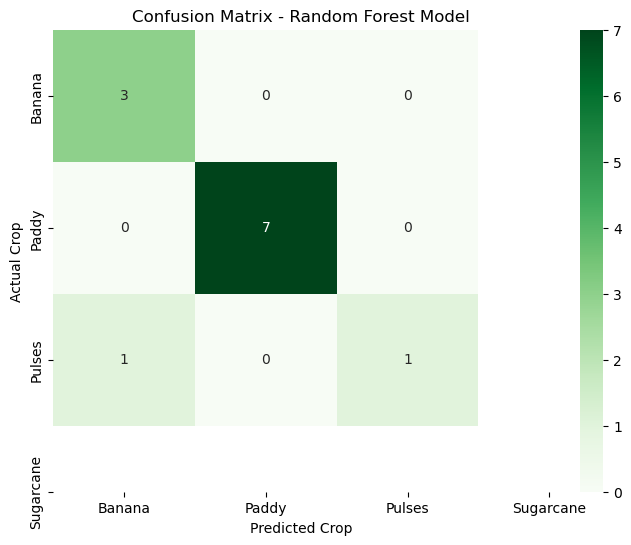

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Confusion Matrix generate 
cm = confusion_matrix(y_test, y_pred)

# 2. Visual- graph 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)

plt.title('Confusion Matrix - Random Forest Model')
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.show()

In [4]:
# 1. Full dataset-kum predict panrom
df['RF_Predicted_Crop'] = rf_model.predict(X)

# 2. Fertilizer logic
def get_fertilizer(row):
    advice = []
    if row['Nitrogen'] < 35: advice.append("Urea: 50kg/Acre")
    if row['Phosphorus'] < 60: advice.append("DAP: 50kg/Acre")
    return " | ".join(advice) if advice else "Nutrients Optimal"

df['Fertilizer_Advisory'] = df.apply(get_fertilizer, axis=1)

# 3. Save the result back to your Downloads folder
output_path = r"C:\Users\vsri9\Downloads\Mayiladuthurai_RF_Final_Report.csv"
df.to_csv(output_path, index=False)

print(f"Success! Final report saved at: {output_path}")

Success! Final report saved at: C:\Users\vsri9\Downloads\Mayiladuthurai_RF_Final_Report.csv


In [ ]:
import pandas as pd

def get_ultra_advisory(row):
    advice = []
    
    # A. Soil Health Status
    if row['Nitrogen'] < 25:
        advice.append("🚩 STATUS: Low Fertility")
    elif row['Nitrogen'] > 75:
        advice.append("✅ STATUS: High Fertility")
    else:
        advice.append("✅ STATUS: Healthy Soil")

    # B. Smarter Irrigation Advice (Updated Ranges)
    if row['Rainfall'] < 150:
        advice.append("💧 WATER: Use Drip Irrigation")
    elif 150 <= row['Rainfall'] <= 800:
        advice.append("💧 WATER: Normal Irrigation")
    else: # 800mm-ku mela pona dhaan drainage alert
        advice.append("🌊 WATER: Needs Good Drainage")

    # C. Smarter Chemical Fertilizer (More Dosage Variations)
    chem = []
    # Nitrogen (Urea) variations
    if row['Nitrogen'] < 20: 
        chem.append("Urea: 25kg (Basal)")
    elif 20 <= row['Nitrogen'] < 40: 
        chem.append("Urea: 15kg (Top Dress)")
    elif 40 <= row['Nitrogen'] < 60:
        chem.append("Urea: 10kg (Top Dress)")
        
    if row['Phosphorus'] < 50: chem.append("DAP: 15kg")
    if row['Potassium'] < 30: chem.append("MOP: 10kg")
    
    if chem: advice.append("🧪 CHEM: " + ", ".join(chem))

    # D. Organic & Pest Alert
    advice.append("🌿 ORG: Farm Yard Manure")
    if row['Humidity'] > 85: # Threshold konjo ethirkkom
        advice.append("🪲 ALERT: High Humidity Risk")
    
    # E. pH Correction
    if row['pH'] < 6.5: advice.append("🛠️ FIX: Apply Lime")
    elif row['pH'] > 7.5: advice.append("🛠️ FIX: Apply Gypsum")

    return " | ".join(advice)

# Model Prediction & Results Apply
df['RF_Predicted_Crop'] = rf_model.predict(X)
df['Fertilizer_Advisory'] = df.apply(get_ultra_advisory, axis=1)

# Interface with Village List
def start_smart_system():
    all_villages = sorted(df['Village'].unique())
    print("\n--- 📍 MAYILADUTHURAI VILLAGE LIST ---")
    for i in range(0, len(all_villages), 3):
        row_v = all_villages[i:i+3]
        print("{:<25} {:<25} {:<25}".format(*row_v if len(row_v)==3 else row_v + [""]*(3-len(row_v))))
    print("="*75)

    while True:
        u_input = input("\nEnter Village Name (or 'exit'): ").strip()
        if u_input.lower() == 'exit':
            df.to_csv("Mayiladuthurai_Final_Report.csv", index=False)
            print("\n✅ Final Report Saved for Power BI!")
            break
        
        match = next((v for v in all_villages if v.lower() == u_input.lower()), None)
        if match:
            data = df[df['Village'] == match].iloc[0]
            print(f"\n📊 RESULTS FOR: {match.upper()}")
            print("-" * 80)
            print(f"🌾 RECOMMENDED CROP     : {data['RF_Predicted_Crop']}")
            print(f"📋 ADVISORY REPORT      : {data['Fertilizer_Advisory']}")
            print(f"🧪 SOIL PARAMETERS      : N={data['Nitrogen']}, P={data['Phosphorus']}, K={data['Potassium']}, pH={data['pH']}")
            print(f"📈 ENVIRONMENTAL DATA   : Rain={data['Rainfall']}mm, Humid={data['Humidity']}%")
            print("-" * 80)
        else:
            
            print(f"❌ Village not found.")

start_smart_system()


--- 📍 MAYILADUTHURAI VILLAGE LIST ---
Agarakkirangudi           Anaimelagaram             Anathandavapuram         
Arulmolithevan            Aruvappadi                Attur                    
Budangudi                 Dharmadanapuram           Elanthoppu               
Ivanallur                 Kadalangudi               Kaduvangudi              
Kali -I                   Kali II Bit               Kanganamputhur           
Keelamarudandanallur      Kesingan                  Kiloy                    
Kodangudi                 Korukkai                  Kovangudi                
Kulichar                  Kurichi                   Maharajapuram            
Manakkudi                 Mannampandal              Maraiyur                 
Mayiladuthurai            Melanallur                Mozhaiyur                
Mudikandanallur           Murugamangalam            Muvalur                  
Nallathukudi              Namasivayapuram           Nidur                    
Pandaravadaimappadugai   